Key Questions
1. **Profitability** — Which product categories generate the most profit, and how much of that comes from sales volume versus per-unit margin?

2. **Returns & discounting** — Does heavier discounting correlate with higher return rates, and how much profit (if any) do returns actually cost each category?

In [79]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [80]:
sns.set_theme(style="whitegrid")

In [81]:
connection = sql.connect('../retail_data/retail_store.db')

In [82]:
##Question 2
## Does heavier discounting correlate with higher return sales?
## If any, how much profit do returns actually cost each category?

discounting_returns_per_category = pd.read_sql_query("""
SELECT cat.CategoryName, 
    AVG(od.DiscountRate) * 100 AS AvgDiscountRate,
    SUM(od.IsReturned) * 100.0 / COUNT(*) AS ReturnRatePercent,
    SUM(CASE WHEN od.IsReturned = 1 
        THEN od.Quantity * (od.UnitPrice * (1 - od.DiscountRate) - od.UnitCost) 
        ELSE 0 END) AS ProfitLossFromReturns
FROM categories AS cat
INNER JOIN products AS p
    ON cat.CategoryID = p.CategoryID
INNER JOIN order_details AS od
    ON p.ProductID = od.ProductID
GROUP BY cat.CategoryName;
"""
, connection)

discounting_returns_per_category.info() ##checking if the transformation is correct

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CategoryName           10 non-null     str    
 1   AvgDiscountRate        10 non-null     float64
 2   ReturnRatePercent      10 non-null     float64
 3   ProfitLossFromReturns  10 non-null     float64
dtypes: float64(3), str(1)
memory usage: 452.0 bytes


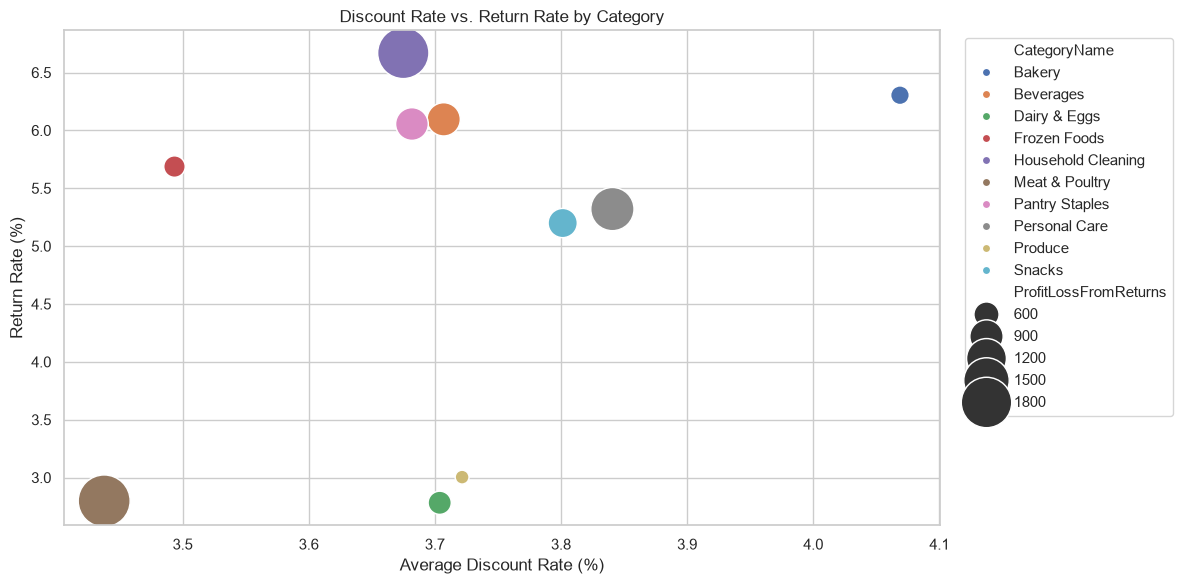

In [ ]:
##Visualization
##Heavier discounting vs. return rate simple scatter plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=discounting_returns_per_category,
    x='AvgDiscountRate',
    y='ReturnRatePercent',
    hue='CategoryName',
    size='ProfitLossFromReturns',
    sizes=(100, 1400),
    ax=ax
)

ax.set_xlabel('Average Discount Rate (%)')
ax.set_ylabel('Return Rate (%)')
ax.set_title('Discount Rate vs. Return Rate by Category')
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


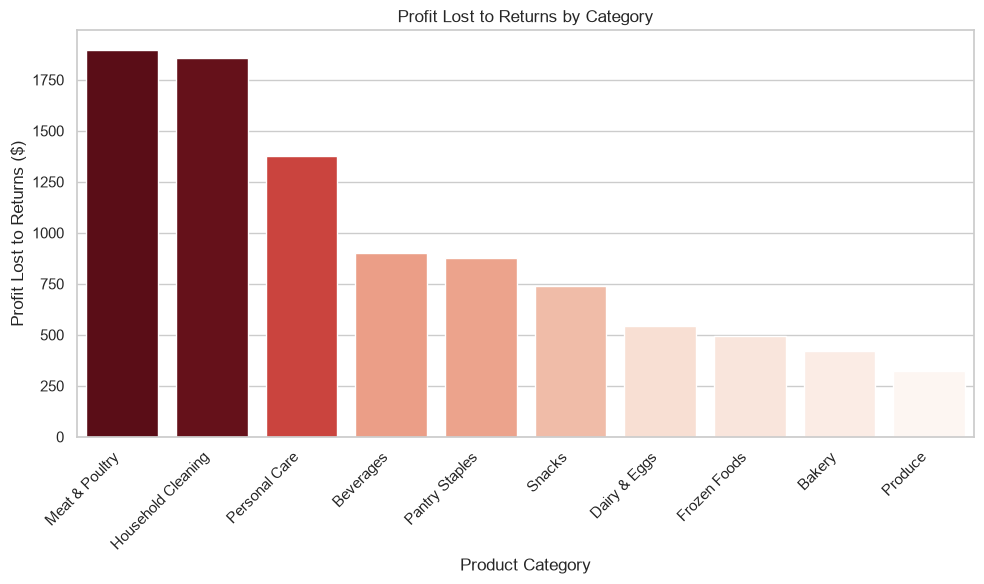

In [92]:
##Visualization
##Profit lost to returns by category
sorted_df = discounting_returns_per_category.sort_values('ProfitLossFromReturns', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sorted_df,
    x='CategoryName',
    y='ProfitLossFromReturns',
    hue='ProfitLossFromReturns',
    palette='Reds',
    legend = False
)

plt.xlabel('Product Category')
plt.ylabel('Profit Lost to Returns ($)')
plt.title('Profit Lost to Returns by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
#Numerical calculations for supporting evidence
order_details = pd.read_csv("../retail_data/order_details.csv") 

r_txn, p_txn = stats.pearsonr(order_details['DiscountRate'], order_details['IsReturned'])
print(f"r = {r_txn:.4f}, p-value = {p_txn:.4f}, n = {len(order_details)}")

r = 0.0059, p-value = 0.3055, n = 30271


In [87]:
r, p = stats.pearsonr(
    discounting_returns_per_category['AvgDiscountRate'],
    discounting_returns_per_category['ReturnRatePercent']
)
print(f"r = {r:.4f}, p-value = {p:.4f}")

r = 0.3624, p-value = 0.3035


## Interpretation

There is no clear visual relationship between discount rate and return rate, which is consistent with the correlation results. The points don't trend in a clear direction — Meat & Poultry sits at the lowest discount and lowest return rate, while Bakery sits at the highest discount and a relatively high return rate. Household Cleaning has the highest return rate despite having only a middling discount rate.

The bubble sizes tell the more interesting part of the story. Meat & Poultry has one of the largest bubbles, but is positioned in the bottom-left (lowest discount and lowest return rate). Its relatively large dollar loss from returns appears to be driven more by the category's overall profit scale than by an unusually high return rate.

Household Cleaning has the second-largest bubble and the highest return rate. Unlike Meat & Poultry, its loss is associated with both a high return rate and relatively healthy profit margins.

Bakery and Frozen Foods are the mirror case worth noting. Both have relatively high return rates (around 6.30% and 5.69%) but have among the smallest bubbles, indicating that their high return rates translate into relatively low dollar losses because of their lower overall profitability.

However, these visual patterns should not be interpreted as a statistically significant relationship between discounting and returns. At the transaction level, the Pearson correlation was r = 0.006 (p > 0.05), indicating essentially no linear relationship between discount rate and return status. At the category level, the correlation was r = 0.36 (p > 0.05), suggesting a weak-to-moderate positive association, but not enough statistical evidence to conclude that the relationship is significant. Therefore, both analyses fail to reject the null hypothesis of no linear association between discounting and returns.
